## Advanced Machine Learning – Project 1  
### Logistic Regression with FISTA and Unlabeled Data

This notebook presents the implementation and experimental analysis of logistic regression models developed for the project.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import time

from src.utils import *
from src.fista_logreg import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

### 1. Data Loading

In this section we load and inspect the datasets used in the experiments.

In [3]:
processed_datasets = {}

datasets = ["biodeg", "magic", "pendigits", "higgs"]

for name in datasets:

    X, y = load_dataset(name)
    X, removed = prepare_dataset(X, threshold=0.9)
    y = y.loc[X.index]
    dataset_summary(X, y, name)
    if removed:
        print(f"Removed features due to high correlation: {removed}\n")

    processed_datasets[name] = {
        "X": X,
        "y": y,
    }

----------------------------------------
Dataset: biodeg
----------------------------------------
Number of samples: 1055
Number of features: 38

Target distribution:
Class
1    699
0    356
Name: count, dtype: int64


Removed features due to high correlation: ['V15', 'V27', 'V39']

----------------------------------------
Dataset: magic
----------------------------------------
Number of samples: 19020
Number of features: 9

Target distribution:
class
1    12332
0     6688
Name: count, dtype: int64


Removed features due to high correlation: ['fConc1']

----------------------------------------
Dataset: pendigits
----------------------------------------
Number of samples: 10992
Number of features: 16

Target distribution:
binaryClass
0    9848
1    1144
Name: count, dtype: int64


----------------------------------------
Dataset: higgs
----------------------------------------
Number of samples: 98049
Number of features: 28

Target distribution:
class
1    51826
0    46223
Name: count, d

During data loading, we perform early preprocessing:
- remove highly correlated features (correlation > 0.9)
- remove rows with missing values (applies only to the Higgs dataset a total of 9 rows removed, which has no impact on the experiments)

### 2. Logistic Regression with FISTA

In this section we compare our implementation of Logistic Lasso regression using the Fast Iterative Shrinkage-Thresholding Algorithm (FISTA) with sklearn implementation.

Experiment description

In order to compare our implementation with the scikit-learn implementation we conduct an experiment - results of which are presented below.

For different values of max_iter, we train models using our FISTA-based implementation with a fixed regularization parameter λ = 1. For the sklearn baseline, we use an equivalent setting with C = 1/𝜆. Additionally, we evaluate an extended version of our method with automatic λ selection, where the optimal value is chosen based on ROC AUC performance on a validation set.

For the sklearn model, we use the following configuration:
LogisticRegression(l1_ratio=1, C=1/lam, solver='liblinear', fit_intercept=False, max_iter=max_iter, random_state=42).

Before training, all datasets are scaled using MinMax normalization and split into training and validation subsets.

For each configuration, we compute the ROC AUC score on the validation set and record the computation time, allowing us to compare both predictive performance and efficiency across methods.

In [4]:
def _print_progress(message):
    sys.stdout.write('\r' + message)
    sys.stdout.flush()


def compare_fista_sklearn(processed_datasets, max_iters=[100, 500, 1000], lam=1.0):
    """
    Compare FISTALogisticLasso with sklearn LogisticRegression (L1).

    Parameters
    ----------
    processed_datasets (dict): Dictionary of datasets with structure {name: {"X": X, "y": y}}
    max_iters (list of int): List of max_iter values to test for FISTA.
    lam (float): Regularization parameter for FISTA and sklearn (C = 1/lam).
    """
    results = []

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))

    for idx, (name, data) in enumerate(processed_datasets.items()):
        
        ax = axes.flatten()[idx]

        X, y = data["X"], data["y"]
        X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_valid = scaler.transform(X_valid)

        # --- FISTA ---
        fista_scores = []
        fista_times = []
        for max_iter in max_iters:
            _print_progress(f"             | dataset: {name} | FISTA                 ")
            _print_progress(f"max_iter={max_iter} ")
            model = FISTALogisticLasso(lam=lam, max_iter=max_iter)

            start = time.perf_counter()
            model.fit(X_train, y_train, auto_validate=False)
            end = time.perf_counter()
            elapsed = end - start

            y_pred = model.predict(X_valid)
            score = roc_auc_score(y_valid, y_pred)
            
            fista_scores.append(score)
            fista_times.append(elapsed)

            results.append({
                "dataset": name,
                "method": "FISTA",
                "max_iter": max_iter,
                "AUC_ROC_score": score,
                "time": elapsed
            })

        #--- FISTA with auto-validate ---
        fista_auto_validate_scores = []
        fista_auto_validate_times = []
        for max_iter in max_iters:
            _print_progress(f"             | dataset: {name} | FISTA (auto-validate) ")
            _print_progress(f"max_iter={max_iter} ")
            model = FISTALogisticLasso(max_iter=max_iter, lambda_values=np.logspace(-6, 1, 20))

            start = time.perf_counter()
            model.fit(X_train, y_train, auto_validate=True, X_valid=X_valid, y_valid=y_valid, measure = "pr_auc")
            end = time.perf_counter()
            elapsed = end - start

            y_pred = model.predict(X_valid)
            score = roc_auc_score(y_valid, y_pred)
            
            fista_auto_validate_scores.append(score)
            fista_auto_validate_times.append(elapsed)

            results.append({
                "dataset": name,
                "method": "FISTA (auto-validate)",
                "max_iter": max_iter,
                "AUC_ROC_score": score,
                "time": elapsed
            })

        # --- sklearn ---
        sklearn_scores = []
        sklearn_times = []
        for max_iter in max_iters:
            _print_progress(f"             | dataset: {name} | sklearn L1            ")
            _print_progress(f"max_iter={max_iter} ")
            clf = LogisticRegression(l1_ratio=1, C=1/lam, solver='liblinear', fit_intercept=False, max_iter=max_iter, random_state=42)

            start = time.perf_counter()
            clf.fit(X_train, y_train)
            end = time.perf_counter()
            elapsed = end - start

            y_pred = clf.predict(X_valid)
            score = roc_auc_score(y_valid, y_pred)
            
            sklearn_scores.append(score)
            sklearn_times.append(elapsed)

            results.append({
                "dataset": name,
                "method": "sklearn L1",
                "max_iter": max_iter,
                "AUC_ROC_score": score,
                "time": elapsed
            })

        # --- plot ---
        ax_score = axes[0, idx]
        ax_time = axes[1, idx]

        all_scores = fista_scores + sklearn_scores + fista_auto_validate_scores
        center = (min(all_scores) + max(all_scores)) / 2

        ax_score.plot(max_iters, fista_scores, marker='o', label='FISTA', color="#FE6100")
        ax_score.plot(max_iters, fista_auto_validate_scores, marker='*', label='FISTA (auto-validate)', color="#DC267F")
        ax_score.plot(max_iters, sklearn_scores, marker='x', label='sklearn L1', color="#648FFF")
        ax_score.set_title(f"Dataset: {name}")
        ax_score.set_xlabel("max_iter")
        ax_score.set_ylabel("ROC-AUC")
        ax_score.set_ylim(center - 0.05, center + 0.05) 
        ax_score.grid(alpha=0.3)

        ax_time.plot(max_iters, fista_times, marker='o', label='FISTA', color="#FE6100", linestyle="dashed")
        ax_time.plot(max_iters, fista_auto_validate_times, marker='*', label='FISTA (auto-validate)', color="#DC267F", linestyle="dashed")
        ax_time.plot(max_iters, sklearn_times, marker='x', label='sklearn L1', color="#648FFF", linestyle="dashed")

        ax_time.set_ylabel("Time (s)")
        ax_time.set_yscale('log')
        ax_time.set_xlabel("max_iter")
        ax_time.set_title(f"{name} – time")
        ax_time.grid(alpha=0.3)
        
    sys.stdout.write('\r' + ' ' * 100 + '\r')
    sys.stdout.flush()

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
    handles,
        labels,
        loc='lower center',
        ncol=3,
        bbox_to_anchor=(0.5, -0.02),
        frameon=False
    )

    plt.suptitle("Comparison of Custom FISTA Implementation with Scikit-learn", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.99])
    plt.show()

    df = pd.DataFrame(results)
    df.to_csv("results.csv", index=False)

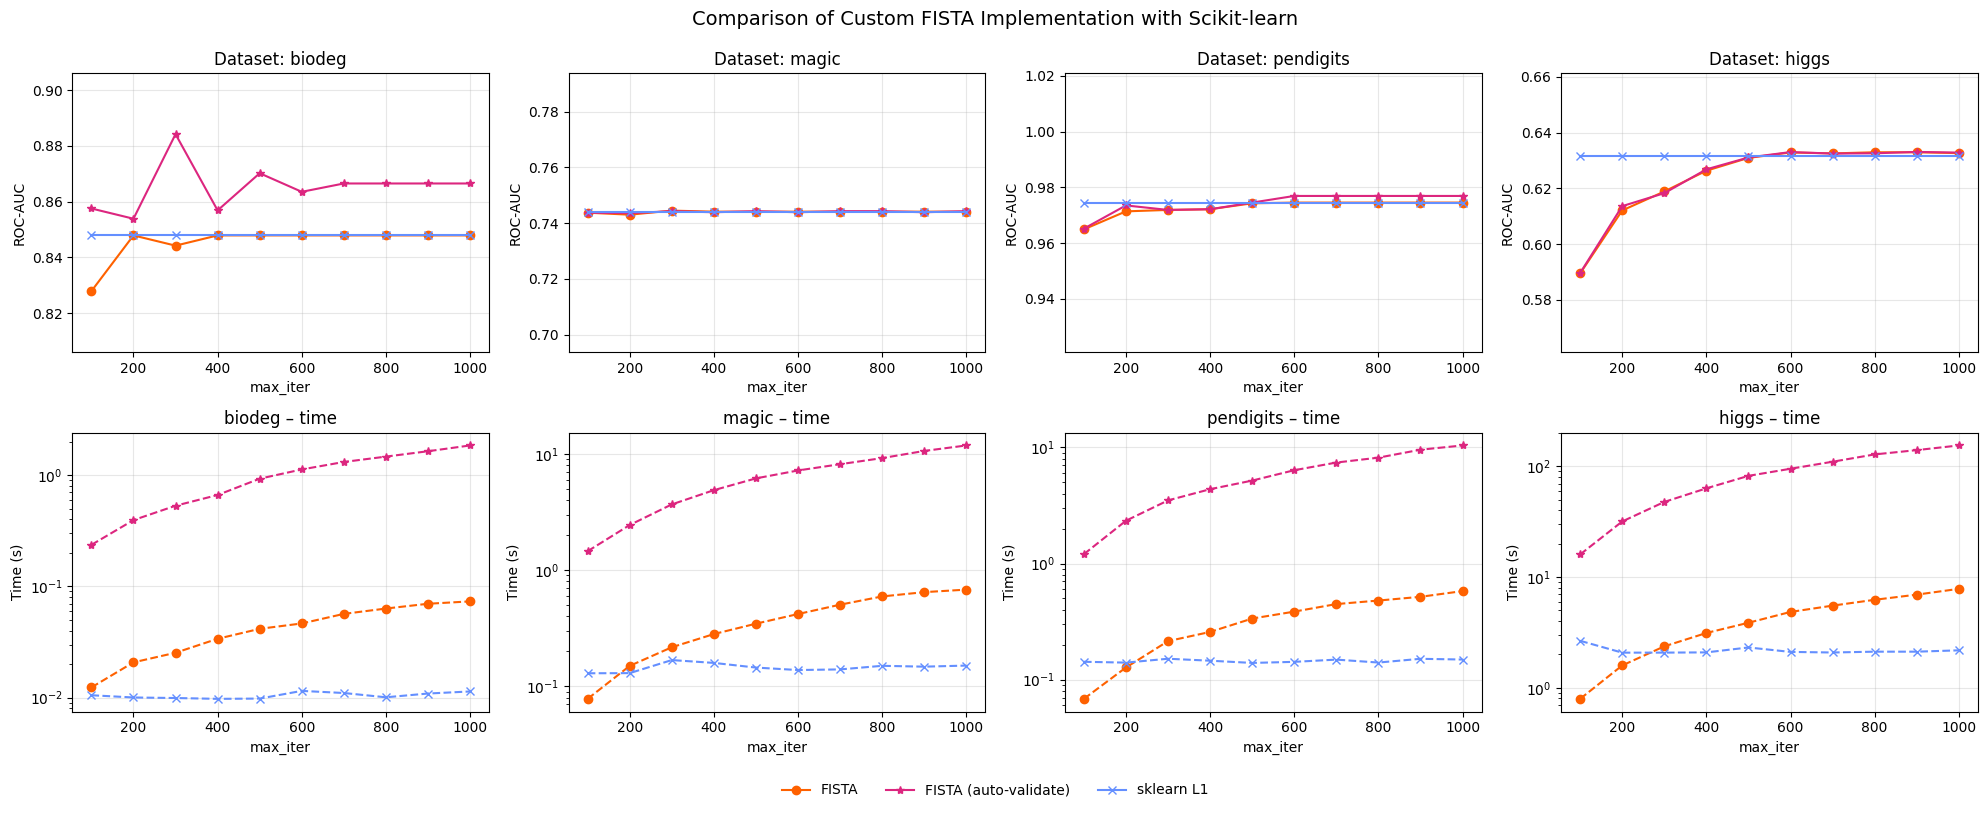

In [5]:
compare_fista_sklearn(processed_datasets, max_iters=np.linspace(100, 1000, 10).astype(int), lam=1.0)